In [1]:
# %pip install "plotly>=6,<7"
# %pip install "dash>=3,<4"
# %pip install "anywidget"

In [2]:
import pandas as pd
import sqlite3
import plotly
import plotly.express as px
import dash

In [19]:
print(f"plotly version == {plotly.__version__}")
print(f"dash version == {dash.__version__}")
print(f"anywidget version == {dash.__version__}")

plotly version == 6.2.0
dash version == 3.2.0
anywidget version == 3.2.0


In [4]:
conn = sqlite3.connect("data/delaware-pcard-transactions.db")

df = pd.read_sql("SELECT * FROM transactions LIMIT 10;", conn)
display(df)

conn.close()

,fiscal_year,fiscal_period,department,division,merchant,category_description,transaction_date,amount
0,2024,4,LEGAL,PUBLIC DEFENDER,UBER TRIP,Travel,2023-10-15,44.34
1,2024,1,JUDICIAL,Superior Court,KALAHARI RESORT - PA,Lodging,2023-07-07,129.00
2,2024,1,JUDICIAL,Superior Court,KALAHARI RESORT - PA ECOM,Lodging,2023-07-06,129.00
3,2024,1,JUDICIAL,Superior Court,AMZN MKTP US*QP9714763,Book Stores,2023-07-09,99.99
4,2024,1,JUDICIAL,Superior Court,KALAHARI RESORT - PA,Lodging,2023-06-30,421.83
5,2024,1,JUDICIAL,Superior Court,KALAHARI RESORT - PA,Lodging,2023-06-30,421.83
6,2024,1,LEGISLATIVE BRANCH,General Assembly House,PRIMO WATER,Miscellaneous And Specialty Retail Stores,2023-07-01,10.25
7,2024,1,LEGISLATIVE BRANCH,General Assembly House,BAUDVILLE INC.,Nondurable Goods Not Elsewhere Classified,2023-07-10,665.27
8,2024,1,LEGISLATIVE BRANCH,General Assembly House,DMDATABASES,Professional Services-Not Elsewhere Classified,2023-07-13,975.00
9,2024,1,LEGISLATIVE BRANCH,General Assembly House,HCGI,Computers Computer Peripheral Equipment Software,2023-07-26,64.00


In [5]:
conn = sqlite3.connect("data/delaware-pcard-transactions.db")

df = pd.read_sql("SELECT COUNT(*) AS num_rows FROM transactions;", conn)
display(df)

conn.close()

,num_rows
0,195566


In [6]:
conn = sqlite3.connect("data/delaware-pcard-transactions.db")

df = pd.read_sql("""
    SELECT 
        department, 
        SUM(amount) AS total_spent,
        COUNT(*) AS num_transactions
    FROM transactions
    GROUP BY department
    ORDER BY total_spent DESC
    LIMIT 10;
""", conn)
display(df)

conn.close()

,department,total_spent,num_transactions
0,DEPT OF CORRECTIONS,24666154.86,18904
1,DEPT OF TRANSPORTATION,13540883.77,18414
2,DEPT OF NATRL RES AND ENV CONT,5254827.35,24084
3,EXECUTIVE,4038290.81,6297
4,DEL TECH AND COMM COLLEGE,3888727.32,10967
5,DEPT OF SAFETY AND HOMELAND,2864776.11,8860
6,DEPT OF HEALTH AND SOCIAL SV,2636324.08,12246
7,APPOQUINIMINK SCHOOL DISTRICT,2390189.95,12399
8,DEPT OF TECHNOLOGY AND INFOR,2070497.45,1386
9,DEPT OF STATE,1956745.29,6240


In [7]:
fig = px.bar(
    df.iloc[::-1],
    x='total_spent',
    y='department',
    template='simple_white',
    title="Top 10 Departments with the Highest Total Spending",
)

fig.show()

In [8]:
conn = sqlite3.connect("data/delaware-pcard-transactions.db")

df = pd.read_sql("""
    SELECT 
        department,
        strftime('%Y-%m', transaction_date) AS year_month,
        COUNT(*) AS transaction_count,
        CAST(SUM(amount) AS INTEGER) AS total_amount
    FROM transactions
    WHERE department IN ('DEPT OF CORRECTIONS', 'DEPT OF TRANSPORTATION')
    GROUP BY department, year_month
    ORDER BY department, year_month;
""", conn)
display(df)

conn.close()

,department,year_month,transaction_count,total_amount
0,DEPT OF CORRECTIONS,2023-06,312,634057
1,DEPT OF CORRECTIONS,2023-07,1230,1492804
2,DEPT OF CORRECTIONS,2023-08,1762,1878673
3,DEPT OF CORRECTIONS,2023-09,1445,1958220
4,DEPT OF CORRECTIONS,2023-10,1384,2056101
5,DEPT OF CORRECTIONS,2023-11,1519,1862929
6,DEPT OF CORRECTIONS,2023-12,1309,1856361
7,DEPT OF CORRECTIONS,2024-01,1543,2305860
8,DEPT OF CORRECTIONS,2024-02,1323,1795816
9,DEPT OF CORRECTIONS,2024-03,1603,1823625


In [9]:
fig = px.bar(
    df,
    x="year_month",
    y="total_amount",
    barmode="group",
    color="department",
    template="simple_white",
    title="Monthly Spending by Dept of Corrections and Dept of Transportation",
)

fig.show()

In [10]:
conn = sqlite3.connect("data/delaware-pcard-transactions.db")

df = pd.read_sql("""
SELECT 
    merchant,
    COUNT(*) AS transaction_count,
    ROUND(SUM(amount), 1) AS total_amount,
    ROUND(AVG(amount), 1) AS average_amount
FROM transactions
GROUP BY merchant
ORDER BY transaction_count DESC
LIMIT 20;
""", conn)
display(df)

conn.close()

,merchant,transaction_count,total_amount,average_amount
0,GRAINGER,3930,1247400.6,317.4
1,VERIZONWRLSS*RTCCR VB,2862,2086234.4,728.9
2,UBER TRIP,2479,63692.8,25.7
3,EASTERN SHORE COFFEE And WA,2022,168660.4,83.4
4,WALMART.COM,1978,257352.1,130.1
5,DSCYF CRIMINAL HIST,1254,62762.0,50.0
6,DMI* DELL K-12/GOVT,1164,1659849.2,1426.0
7,INTERNATIONAL TRANSACTION,1036,6686.8,6.5
8,COL PRKNG JSTCE CTR Q08,986,8141.0,8.3
9,DLTCRP BACKGROUND CHECK,954,23850.0,25.0


In [11]:
conn = sqlite3.connect("data/delaware-pcard-transactions.db")

vendor_summary = pd.read_sql("""
    -- Step 1: Identify the top 5 vendors by number of transactions
    WITH top_5_vendors AS (
        SELECT
            merchant,
            COUNT(amount) AS num_transactions
        FROM transactions
        WHERE amount > 0
        GROUP BY merchant
        ORDER BY num_transactions DESC
        LIMIT 5
    )
    -- Step 2: Generate the monthly summary ONLY for these filtered vendors
    SELECT
        t.merchant,
        strftime('%Y-%m', t.transaction_date) AS year_month,
        COUNT(*) AS transaction_count,
        CAST(SUM(t.amount) AS INTEGER) AS total_amount
    FROM transactions t
    JOIN top_5_vendors tv ON t.merchant = tv.merchant
    GROUP BY t.merchant, year_month
    ORDER BY 
        t.merchant,
        year_month;
""", conn)
display(vendor_summary)

conn.close()

,merchant,year_month,transaction_count,total_amount
0,EASTERN SHORE COFFEE And WA,2023-06,12,274
1,EASTERN SHORE COFFEE And WA,2023-07,173,11798
2,EASTERN SHORE COFFEE And WA,2023-08,185,11321
3,EASTERN SHORE COFFEE And WA,2023-09,161,11336
4,EASTERN SHORE COFFEE And WA,2023-10,182,11879
...,...,...,...,...
60,WALMART.COM,2024-02,156,15828
61,WALMART.COM,2024-03,202,26009
62,WALMART.COM,2024-04,170,23810
63,WALMART.COM,2024-05,250,35458


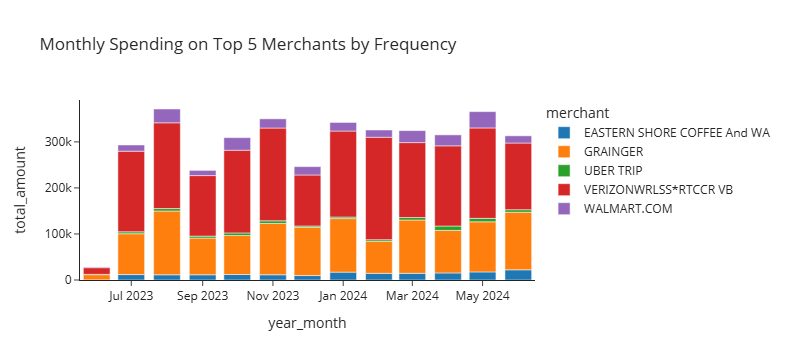

In [14]:
fig_merchant_top5 = px.bar(
    vendor_summary,
    x='year_month',
    y='total_amount',
    color='merchant',
    template="simple_white",
    title="Monthly Spending on Top 5 Merchants by Frequency",
)

fig_merchant_top5.show()

In [17]:
from dash import Dash, html

app = Dash()

# Requires Dash 2.17.0 or later
app.layout = [html.Div(children='Hello World')]

if __name__ == '__main__':
    app.run(debug=True)
